In [11]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

In [1]:
import json
from pathlib import Path
import pandas as pd

In [2]:
data_path = Path("../data/train.json")

with open(data_path, "r", encoding="utf-8") as f:
    train_data = json.load(f)

print(type(train_data))
print(len(train_data))
print(train_data[0])

<class 'list'>
15000
{'text': 'i need you to book me a flight from ft lauderdale to houston on southwest', 'intent': 'book_flight', 'id': 'train-0'}


In [3]:
train_df = pd.DataFrame(train_data)

In [4]:
print(train_df.shape)
print(train_df.columns.tolist())
print(train_df["intent"].nunique())

(15000, 3)
['text', 'intent', 'id']
150


In [5]:
intent_counts = train_df["intent"].value_counts()

print(intent_counts.head(10))
print(intent_counts.describe())

intent
book_flight        100
exchange_rate      100
cancel             100
gas                100
spelling           100
lost_luggage       100
order_status       100
timezone           100
update_playlist    100
find_phone         100
Name: count, dtype: int64
count    150.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: count, dtype: float64


In [6]:
X = train_df["text"]
y = train_df["intent"]

print(X.head())
print()
print(y.head())

0    i need you to book me a flight from ft lauderd...
1    my check engine light is on and i need to take...
2         is the company party on my list of reminders
3                                      are you a human
4     i need to do cleaning so add it to my to do list
Name: text, dtype: object

0             book_flight
1    schedule_maintenance
2                reminder
3           are_you_a_bot
4        todo_list_update
Name: intent, dtype: object


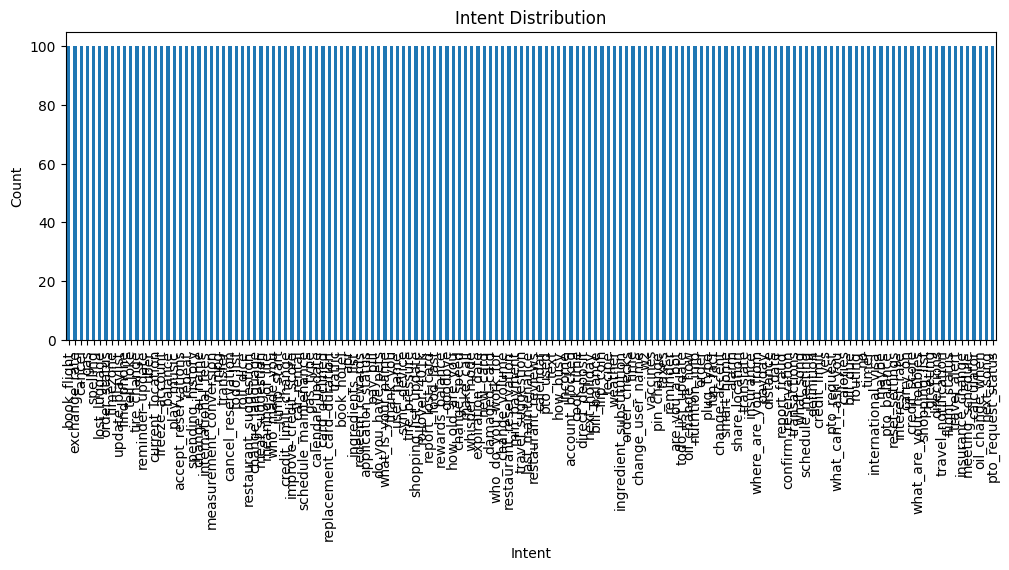

In [7]:
import matplotlib.pyplot as plt

intent_counts = train_df["intent"].value_counts()

plt.figure(figsize=(12,4))
intent_counts.plot(kind="bar")
plt.title("Intent Distribution")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.show()

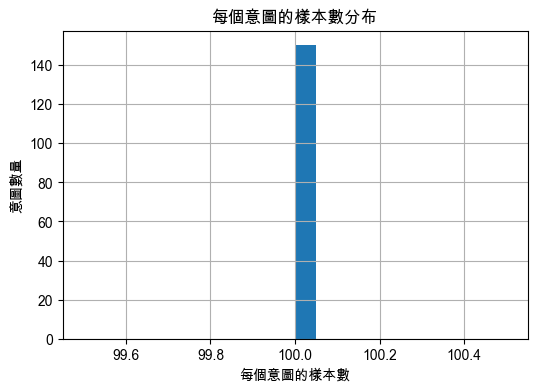

In [12]:
plt.figure(figsize=(6,4))
train_df["intent"].value_counts().hist(bins=20)

plt.title("每個意圖的樣本數分布")
plt.xlabel("每個意圖的樣本數")
plt.ylabel("意圖數量")

plt.show()

In [9]:
train_df["intent"].value_counts().describe()

count    150.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: count, dtype: float64

Dataset Overview

Total samples: 15,000

Number of intents: 150

Samples per intent: 100

Dataset is perfectly balanced

In [14]:
train_df["text_length"] = train_df["text"].apply(lambda x: len(x.split()))

train_df["text_length"].head()

0    15
1    15
2     9
3     4
4    13
Name: text_length, dtype: int64

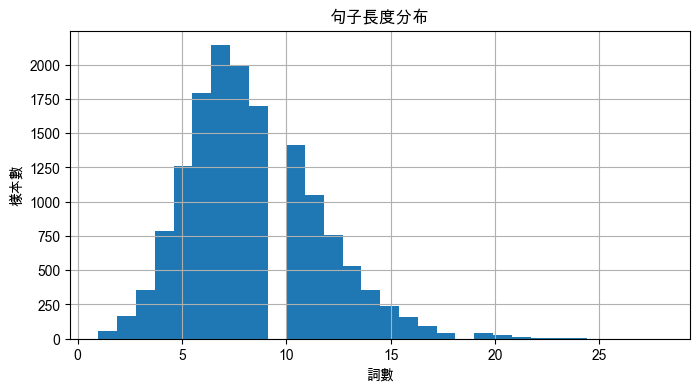

In [15]:
plt.figure(figsize=(8,4))
train_df["text_length"].hist(bins=30)

plt.title("句子長度分布")
plt.xlabel("詞數")
plt.ylabel("樣本數")

plt.show()

In [16]:
train_df["text_length"].describe()

count    15000.000000
mean         8.339200
std          3.191868
min          1.000000
25%          6.000000
50%          8.000000
75%         10.000000
max         28.000000
Name: text_length, dtype: float64

資料集中使用者查詢句子平均長度約 8 個詞，
75% 的句子長度在 10 個詞以內，最長為 28 個詞。
整體句子長度較短，符合對話式查詢 (conversational queries) 的特性。

這個分析的作用是支持後面模型設計，例如：

Tokenizer 長度設定

BERT 的 max_length
例如可以說：
設定 max_length = 32 即可覆蓋全部樣本

In [17]:
from collections import Counter

all_words = " ".join(train_df["text"]).split()
word_counts = Counter(all_words)

word_counts.most_common(20)

[('my', 5528),
 ('i', 5437),
 ('to', 5428),
 ('the', 3992),
 ('you', 2966),
 ('a', 2531),
 ('for', 2520),
 ('what', 2506),
 ('me', 2420),
 ('is', 2235),
 ('how', 2065),
 ('do', 1912),
 ('on', 1797),
 ('can', 1793),
 ('in', 1647),
 ('of', 1466),
 ('need', 1306),
 ('please', 1134),
 ('card', 1103),
 ('tell', 998)]

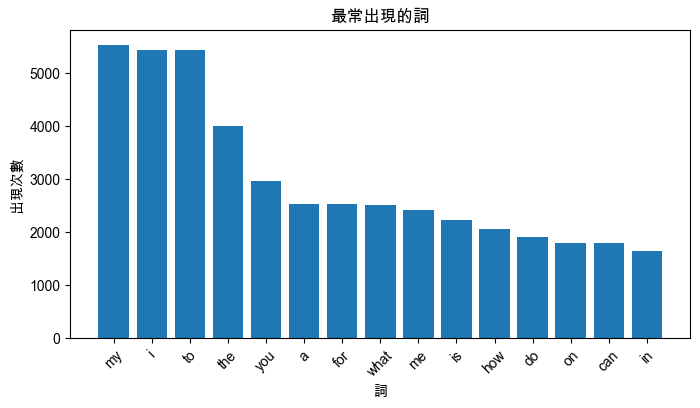

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

top_words = word_counts.most_common(15)

words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

plt.figure(figsize=(8,4))
plt.bar(words, counts)

plt.title("最常出現的詞")
plt.xlabel("詞")
plt.ylabel("出現次數")

plt.xticks(rotation=45)
plt.show()

高頻詞包含 "I", "my", "what", "how" 等對話式詞彙，
顯示資料主要來自使用者與系統的自然語言查詢。